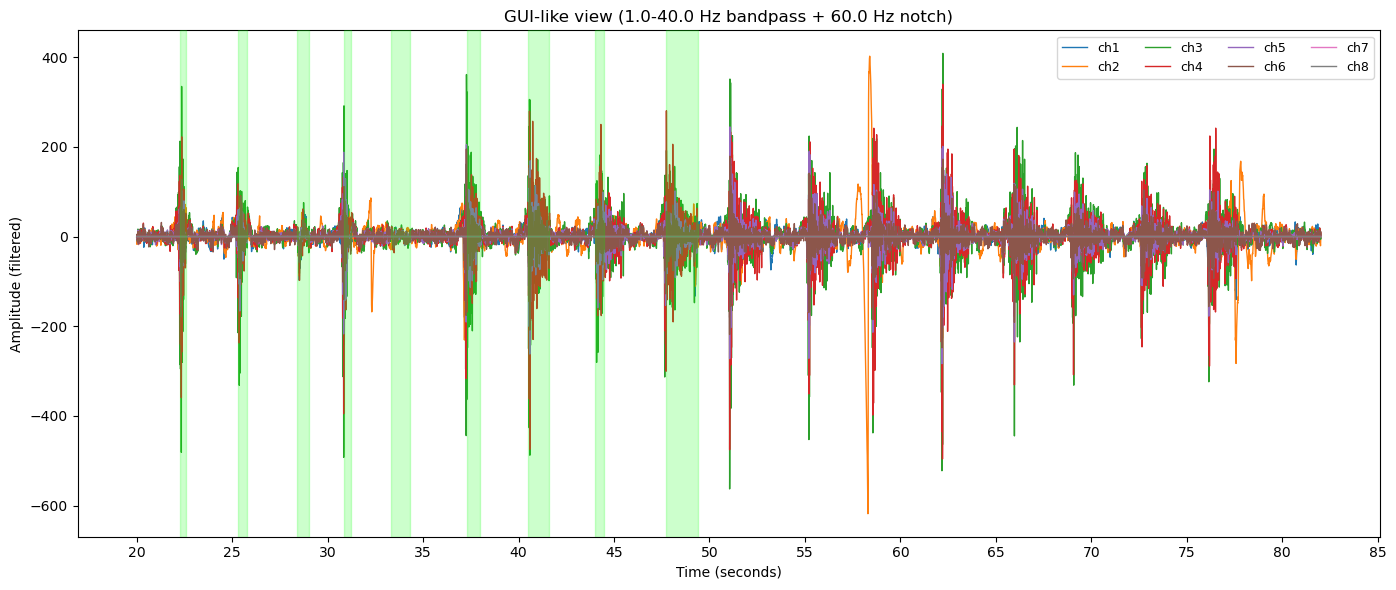

In [ ]:
# Note: This recreates the graphs from the CSV (not actually necesarry) and visualizes the time windows that we manually measure (to train)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch

# ====== CONFIG ======
FS = 250
FILE = r"OpenBCISession_jclench_2_15_1\BrainFlow-RAW_jclench_2_15_1_0.csv"

# set to None to use full recording
START_S = 20   # e.g. 5
END_S   = None   # e.g. 15

BAND_LOW = 1.0
BAND_HIGH = 40.0
NOTCH_HZ = 60.0
NOTCH_Q = 30.0

# ====== LOAD ======
df = pd.read_csv(FILE, sep="\t", header=None)
X = df.iloc[:, 1:9].apply(pd.to_numeric, errors="coerce").to_numpy()
X = X[~np.isnan(X).any(axis=1)]

# ====== TIME AXIS ======
t_full = np.arange(len(X)) / FS


# ====== OPTIONAL WINDOW ======
start_idx = 0 if START_S is None else int(START_S * FS)
end_idx = len(X) if END_S is None else int(END_S * FS)

X = X[start_idx:end_idx]
# t = t_full[start_idx:end_idx] - t_full[start_idx] -- move start to 0
t = t_full[start_idx:end_idx]


# ====== GUI-LIKE PREPROCESSING ======
X = X - X.mean(axis=0, keepdims=True)

b, a = butter(4, [BAND_LOW/(FS/2), BAND_HIGH/(FS/2)], btype="band")
X = filtfilt(b, a, X, axis=0)

bn, an = iirnotch(NOTCH_HZ/(FS/2), NOTCH_Q)
X = filtfilt(bn, an, X, axis=0)

# ====== PLOT ======
plt.figure(figsize=(14, 6))

for ch in range(8):
    plt.plot(t, X[:, ch], label=f"ch{ch+1}", linewidth=1)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (filtered)")
plt.title(f"GUI-like view ({BAND_LOW}-{BAND_HIGH} Hz bandpass + {NOTCH_HZ} Hz notch)")
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
#plt.ylim(0,200)


# show where we clenched (roughly)
# Note: range of clench matters (think start is the time we want)
# clench_times = [22.5, 25.6, 28.6, 30.9, 33.6, 37.7, 41.2, 44.7, 48.3, 51.3, 56, 59.1]

# for mark_time in clench_times:
#     plt.axvline(mark_time, color="green", alpha=0.4, linewidth=3)

clench_times = [
    (22.281, 22.6),
    (25.31, 25.8),
    (28.41, 29),
    (30.85, 31.21),
    (33.3, 34.3),
    (37.3, 38),
    (40.5, 41.6),
    (44,44.5),
    (47.7,49.4)]
for start_mark_time, end_mark_time in clench_times:
    plt.axvspan(start_mark_time, end_mark_time,
            color="lime",
            alpha=0.2,
            zorder = 10)


plt.xticks(np.arange(np.floor(t[0]/5)*5, np.ceil(t[-1]/5)*5 + 0.001, 5))
plt.show()


Detected events:
1: start=22.332s  end=22.340s  duration=0.008s
2: start=22.352s  end=22.352s  duration=0.000s
3: start=25.372s  end=25.372s  duration=0.000s
4: start=25.400s  end=25.400s  duration=0.000s
5: start=30.788s  end=30.792s  duration=0.004s
6: start=30.836s  end=30.844s  duration=0.008s
7: start=37.256s  end=37.260s  duration=0.004s
8: start=37.272s  end=37.276s  duration=0.004s
9: start=37.288s  end=37.288s  duration=0.000s
10: start=37.304s  end=37.304s  duration=0.000s
11: start=40.552s  end=40.556s  duration=0.004s
12: start=40.572s  end=40.572s  duration=0.000s
13: start=40.588s  end=40.596s  duration=0.008s
14: start=40.612s  end=40.612s  duration=0.000s
15: start=47.656s  end=47.656s  duration=0.000s
16: start=47.728s  end=47.728s  duration=0.000s
17: start=51.052s  end=51.060s  duration=0.008s
18: start=51.072s  end=51.076s  duration=0.004s
19: start=51.088s  end=51.092s  duration=0.004s
20: start=51.104s  end=51.104s  duration=0.000s
21: start=51.120s  end=51.124s  

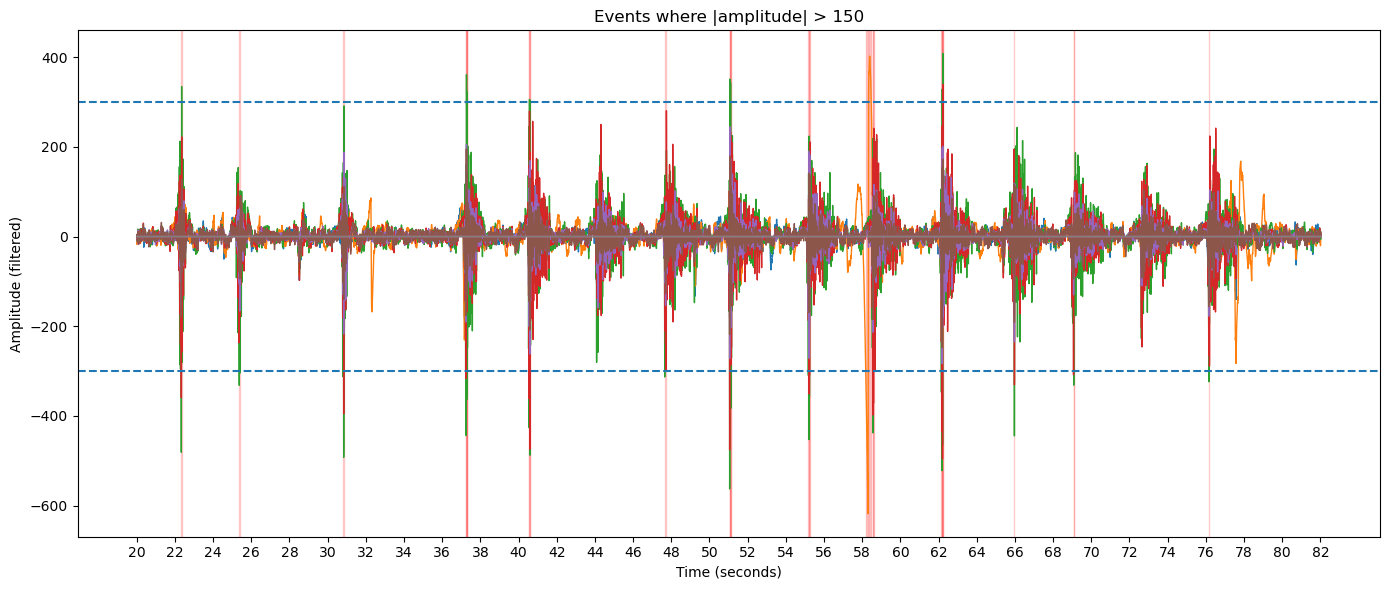

In [ ]:
# Note: This is just to visually make it easy to count the spikes (in order to quickly test accuracy of predictions)

import numpy as np
import matplotlib.pyplot as plt

THRESH = 300

# -----------------------------------
# 1) Detect threshold crossings
# -----------------------------------
mask = (X > THRESH) | (X < -THRESH)
mask_any = mask.any(axis=1)

events = []
in_event = False

for i in range(len(mask_any)):
    if mask_any[i] and not in_event:
        start_idx = i
        in_event = True
    elif not mask_any[i] and in_event:
        end_idx = i - 1
        events.append((start_idx, end_idx))
        in_event = False

# If recording ends while still in event
if in_event:
    events.append((start_idx, len(mask_any) - 1))

# -----------------------------------
# 2) Print timestamps
# -----------------------------------
print("Detected events:")
for idx, (s, e) in enumerate(events):
    start_t = t[s]
    end_t = t[e]
    duration = end_t - start_t
    print(f"{idx+1}: start={start_t:.3f}s  end={end_t:.3f}s  duration={duration:.3f}s")

# -----------------------------------
# 3) Plot
# -----------------------------------
plt.figure(figsize=(14, 6))

for ch in range(8):
    plt.plot(t, X[:, ch], linewidth=1)

for s, e in events:
    plt.axvspan(t[s], t[e], color="red", alpha=0.2)

plt.axhline(THRESH, linestyle="--")
plt.axhline(-THRESH, linestyle="--")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (filtered)")
plt.title("Events where |amplitude| > 150")
plt.tight_layout()
ticks = np.arange(np.floor(t[0]), np.ceil(t[-1]) + 0.001, 2)
plt.xticks(ticks, [f"{int(x)}" for x in ticks])
plt.show()

In [ ]:
# Note: This runs linear regression to train the model
# 16 vectors; for each channel, we measure root-mean-squared and variance

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

#
# 1. Make sample-level labels from your time intervals
#
labels = np.zeros(len(t), dtype=int)
for a, b in clench_times:
    labels[(t >= a) & (t <= b)] = 1

#
# 2. Window the signal
# Each window is 250ms, but between every two consecutive windows there is a 125ms overlap; this helps reduce error
# in detecting events that would get split between two windows (in a scenario w/out an overlap)
#
win_s = 0.25      # 250 ms windows
stride_s = 0.125  # 125 ms step (50% overlap)

W = int(win_s * FS)
S = int(stride_s * FS)

X_windows = []
y_windows = []
t_windows = []

min_frac = 0.30

for start in range(0, len(X) - W + 1, S):
    end = start + W

    Xw = X[start:end, :]
    lw = labels[start:end]

    y = 1 if (lw.mean() >= min_frac) else 0

    X_windows.append(Xw)
    y_windows.append(y)
    t_windows.append(t[start + W//2])  # center time of window

X_windows = np.stack(X_windows, axis=0)
y_windows = np.array(y_windows)
t_windows = np.array(t_windows)

print("X_windows shape:", X_windows.shape)
print("y_windows counts:", np.bincount(y_windows))

#
# 3. Extract features per window (RMS + variance per each of 8 channels)
#
rms = np.sqrt(np.mean(X_windows**2, axis=1))   # (n_windows, 8)
var = np.var(X_windows, axis=1)                # (n_windows, 8)
F = np.concatenate([rms, var], axis=1)         # (n_windows, 16)

#
# 4. Split train/test by TIME (train only up to 50 seconds)
# Note: 50 seconds is arbitrary; that's just about the window that I manually labeled / trained the model on
#
train_mask = t_windows <= 50
test_mask  = t_windows > 50

F_train, y_train = F[train_mask], y_windows[train_mask]
F_test,  y_test  = F[test_mask],  y_windows[test_mask]

print("Train windows:", F_train.shape[0], " Test windows:", F_test.shape[0])

# Guardrails: make sure training isn't all one class
print("Train label counts:", np.bincount(y_train) if y_train.size else "EMPTY")
print("Test  label counts:", np.bincount(y_test)  if y_test.size else "EMPTY")

#
# 5. Train model (16D regression; good luck picturing that)
#
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(F_train, y_train)

pred_all = clf.predict(F)
prob_all = clf.predict_proba(F)[:, 1]

# Evaluate ONLY on the >50s region (the untrained data)
# Note: When we actually control the drone, this >50s won't be a thing because we will be prediciting in live time (not from pre-recorded data)
pred_test = pred_all[test_mask]

print("Confusion matrix (test >50s):\n", confusion_matrix(y_test, pred_test))
print(classification_report(y_test, pred_test, digits=3))

#
# 6. Save dataset
#
cols = (
    ["t_center"] +
    [f"rms_ch{i+1}" for i in range(8)] +
    [f"var_ch{i+1}" for i in range(8)] +
    ["label", "pred", "prob"]
)

out = np.column_stack([t_windows, F, y_windows, pred_all, prob_all])
pd.DataFrame(out, columns=cols).to_csv("windows_features_labels_preds.csv", index=False)
print("Wrote: windows_features_labels_preds.csv")

X_windows shape: (499, 62, 8)
y_windows counts: [437  62]
Train windows: 241  Test windows: 258
Train label counts: [179  62]
Test  label counts: [258]
Confusion matrix (test >50s):
 [[159  99]
 [  0   0]]
              precision    recall  f1-score   support

           0      1.000     0.616     0.763       258
           1      0.000     0.000     0.000         0

    accuracy                          0.616       258
   macro avg      0.500     0.308     0.381       258
weighted avg      1.000     0.616     0.763       258

Wrote: windows_features_labels_preds.csv


c:\Users\justi\anaconda3\envs\ece3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\justi\anaconda3\envs\ece3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\justi\anaconda3\envs\ece3\Lib\site-packages\sklearn\metrics\_clas

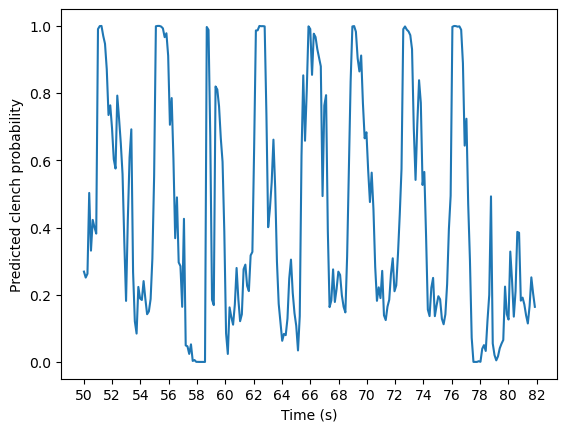

In [ ]:
# This visualizes the prediction of the trials we didn't test based on our trained model

df = pd.read_csv("windows_features_labels_preds.csv")

unannotated = df[df["t_center"] > 50].copy()
annotated   = df[df["t_center"] <= 50].copy()

plt.figure()
plt.plot(unannotated["t_center"], unannotated["prob"])
# plt.axhline(0.5, linestyle="--") # Optional line to visualize threshold (0.5 is arbitrary; we'll fine tune this)
plt.xlabel("Time (s)")
plt.ylabel("Predicted clench probability")

# 2-second tick spacing (visual for graph -- easier to visually check accuracy)
tmin = np.floor(unannotated["t_center"].min())
tmax = np.ceil(unannotated["t_center"].max())
ticks = np.arange(tmin, tmax + 0.001, 2)
plt.xticks(ticks, [f"{int(x)}" for x in ticks])

plt.show()